# Model 01 — Logistic Regression (Logistics Delay Prediction)

Every logistics operation lives under the pressure of the same question: *will this shipment arrive on time?* The answer is never just about distance. It is a compound of route type, dock congestion, operator experience, cargo weight, and the small decisions made at 2 AM when the yard is half-empty. These interactions are hard to internalize across thousands of daily shipments — but they are learnable from data.

This project applies **Logistic Regression** to predict whether a shipment will be delayed before it leaves the facility. The choice of model is deliberate: Logistic Regression does not just classify — it assigns a *probability* to each shipment. That probability is the operationally useful output. A 52% delay probability and an 89% delay probability both round to "high risk," but they represent very different intervention decisions for a dispatcher.

What this notebook delivers is not just accuracy. It delivers a readable set of coefficients that translate directly into operational levers: which variables push delay probability up, which protect against it, and by how much. The simulator at the end turns the model into a what-if tool for pre-departure analysis.

---
**Data source:** `logistics_shipments_data.csv`  
**Output:** metrics, coefficient-based interpretability, decision maps, and a shipment scenario simulator


## Section 1 — Setup

Reproducibility is not optional in operations. If a model gives different results every run, it cannot be trusted in a production environment. We fix a global random seed, import all libraries upfront, and configure plot aesthetics once — so every chart in this notebook is generated consistently.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from scipy import stats

# Global seed — everything downstream is reproducible
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Libraries loaded. Random state:", RANDOM_STATE)


Libraries loaded. Random state: 42


## Section 2 — Load Data

The dataset contains **1,500 simulated shipment records** from a logistics operation covering urban, mixed, and long-haul routes. Each row represents one shipment, described by 9 operational features: route geometry (distance, stops, route type), cargo characteristics (weight, priority), facility conditions (loading time, dock wait time), workforce attributes (operator experience), and departure context (shift). The target variable `delayed` is binary — 1 if the shipment arrived late, 0 if it was on time.

> *Note: The raw dataset in this project was generated using a simulation script that models realistic logistics conditions — including how dock congestion, urban traffic density, and operator inexperience compound to produce delays at a rate of approximately 67%. The `.csv` file used here is the final output of that process, loaded directly as you would in a real operational context.*

The try/except block below makes the notebook portable: it runs locally if the CSV is in the same folder, and falls back to GitHub if running on Google Colab.


In [2]:
try:
    df = pd.read_csv("logistics_shipments_data.csv")
except FileNotFoundError:
    df = pd.read_csv("https://raw.githubusercontent.com/LozanoLsa/01-Logistic-Regression-Logistics/main/logistics_shipments_data.csv")
    # FileNotFoundError is intentionally specific — a bare except would silently swallow real data errors

df.head()


,distance_km,weight_kg,num_stops,priority,loading_time_min,dock_wait_time_min,operator_experience_yrs,route_type,departure_shift,delayed
0,345.71,573.48,3,0,59.76,18.03,3.80,long_haul,day,1
1,144.00,550.16,5,1,53.70,28.73,7.52,urban,day,1
2,412.57,1330.06,1,0,108.53,31.82,5.45,mixed,day,1
3,441.08,932.12,5,1,43.66,52.89,7.37,urban,night,1
4,10.00,715.31,3,1,65.96,36.56,5.58,mixed,night,0


## Section 3 — Quick Sanity Checks

Before any modeling, we validate what we actually loaded. The checks below catch the silent issues that cause wrong results: missing values that survived a CSV export, columns with unexpected dtypes, and class imbalance that would make accuracy a misleading metric. Real datasets usually try to hurt you — so we look before we touch.


In [3]:
# Sanity checks. Real datasets usually try to hurt you 🙂
print("Shape:", df.shape)
print("\n--- Data types ---")
df.info()


Shape: (1500, 10)

--- Data types ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   distance_km              1500 non-null   float64
 1   weight_kg                1500 non-null   float64
 2   num_stops                1500 non-null   int64  
 3   priority                 1500 non-null   int64  
 4   loading_time_min         1500 non-null   float64
 5   dock_wait_time_min       1500 non-null   float64
 6   operator_experience_yrs  1500 non-null   float64
 7   route_type               1500 non-null   object 
 8   departure_shift          1500 non-null   object 
 9   delayed                  1500 non-null   int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 117.3+ KB


In [4]:
print("--- Missing values ---")
print(df.isna().sum())
print("\n--- Target class balance ---")
print(df["delayed"].value_counts())
print("\n--- Delay rate ---")
print(df["delayed"].value_counts(normalize=True).rename({0: "on_time", 1: "delayed"}))


--- Missing values ---
distance_km                0
weight_kg                  0
num_stops                  0
priority                   0
loading_time_min           0
dock_wait_time_min         0
operator_experience_yrs    0
route_type                 0
departure_shift            0
delayed                    0
dtype: int64

--- Target class balance ---
delayed
1    1017
0     483
Name: count, dtype: int64

--- Delay rate ---
delayed
delayed    0.678
on_time    0.322
Name: proportion, dtype: float64


In [5]:
print("--- Categorical variables ---")
print("route_type:", df["route_type"].value_counts().to_dict())
print("departure_shift:", df["departure_shift"].value_counts().to_dict())
print("\n--- Numeric summary ---")
df.describe().round(2)


--- Categorical variables ---
route_type: {'urban': 593, 'mixed': 537, 'long_haul': 370}
departure_shift: {'day': 900, 'night': 600}

--- Numeric summary ---


,distance_km,weight_kg,num_stops,priority,loading_time_min,dock_wait_time_min,operator_experience_yrs,delayed
count,1500.00,1500.00,1500.00,1500.0,1500.00,1500.00,1500.00,1500.00
mean,298.75,793.20,2.95,0.5,60.46,30.24,5.03,0.68
std,145.73,394.68,1.42,0.5,20.06,14.72,2.86,0.47
min,10.00,50.00,1.00,0.0,10.00,0.00,0.00,0.00
25%,198.16,520.87,2.00,0.0,46.63,20.29,3.08,0.00
50%,300.52,798.12,3.00,1.0,60.64,29.26,4.94,1.00
75%,393.16,1059.11,4.00,1.0,73.85,40.44,6.98,1.00
max,776.83,2023.81,5.00,1.0,124.83,79.41,17.08,1.00


## Section 4 — Exploratory Data Analysis

EDA is hypothesis formation, not just plotting. The purpose here is to understand how `delayed` relates to the operational drivers we have available — before the model touches any of it. We focus on three questions:

1. **Are distributions healthy?** Any unexpected skew or outliers that would distort scaling?
2. **Do categorical variables discriminate?** Is delay rate meaningfully different across route types and shifts?
3. **Are numeric features separating the two classes?** Boxplots by class will show where delay probability diverges.

The patterns here should map to what the model learns — if they don't, that's a signal worth investigating.


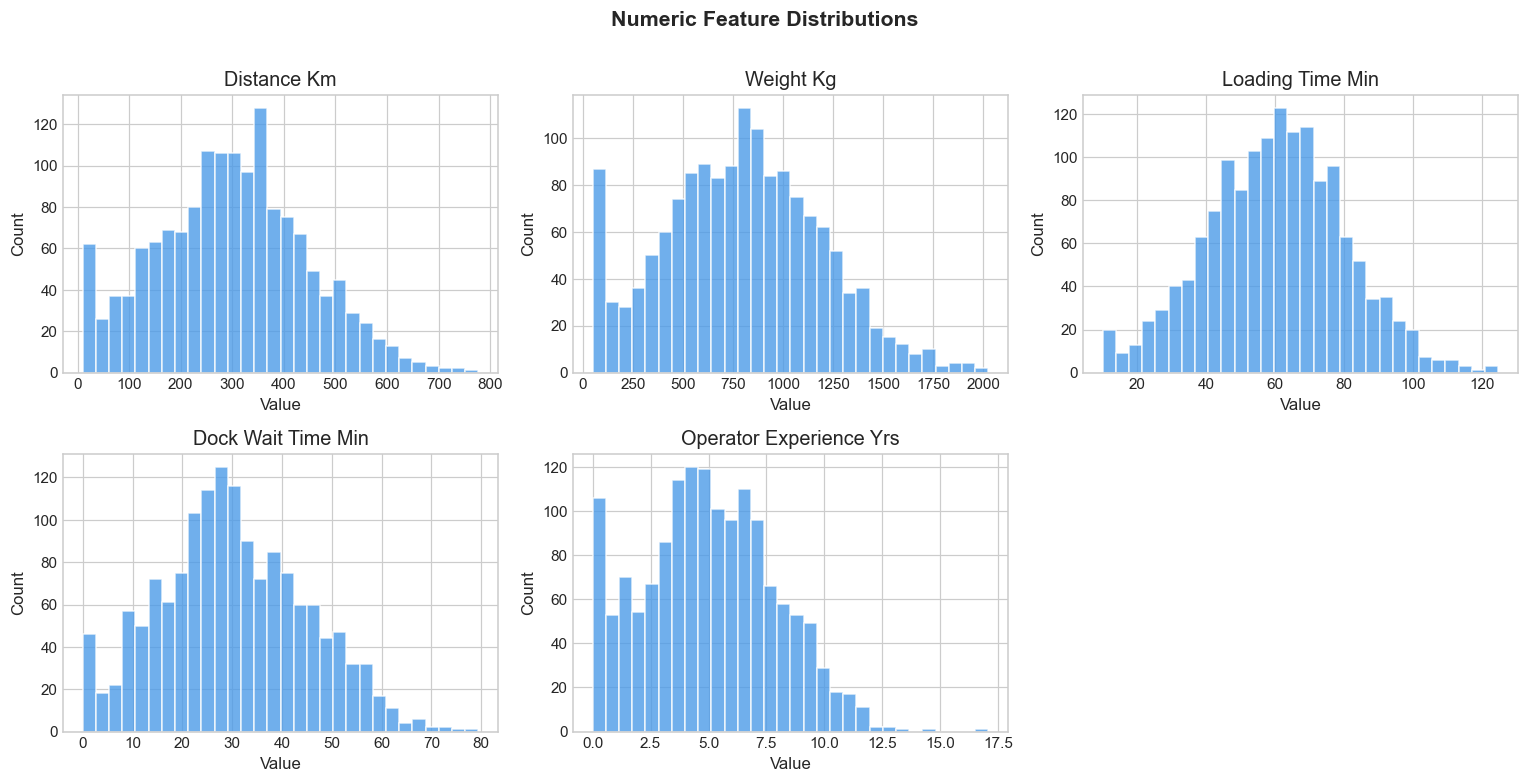

In [6]:
# Numeric feature distributions — looking for skew and range issues
numeric_cols = ["distance_km", "weight_kg", "loading_time_min",
                "dock_wait_time_min", "operator_experience_yrs"]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="#4C9BE8", edgecolor="white", alpha=0.8)
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
axes[-1].set_visible(False)
plt.suptitle("Numeric Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


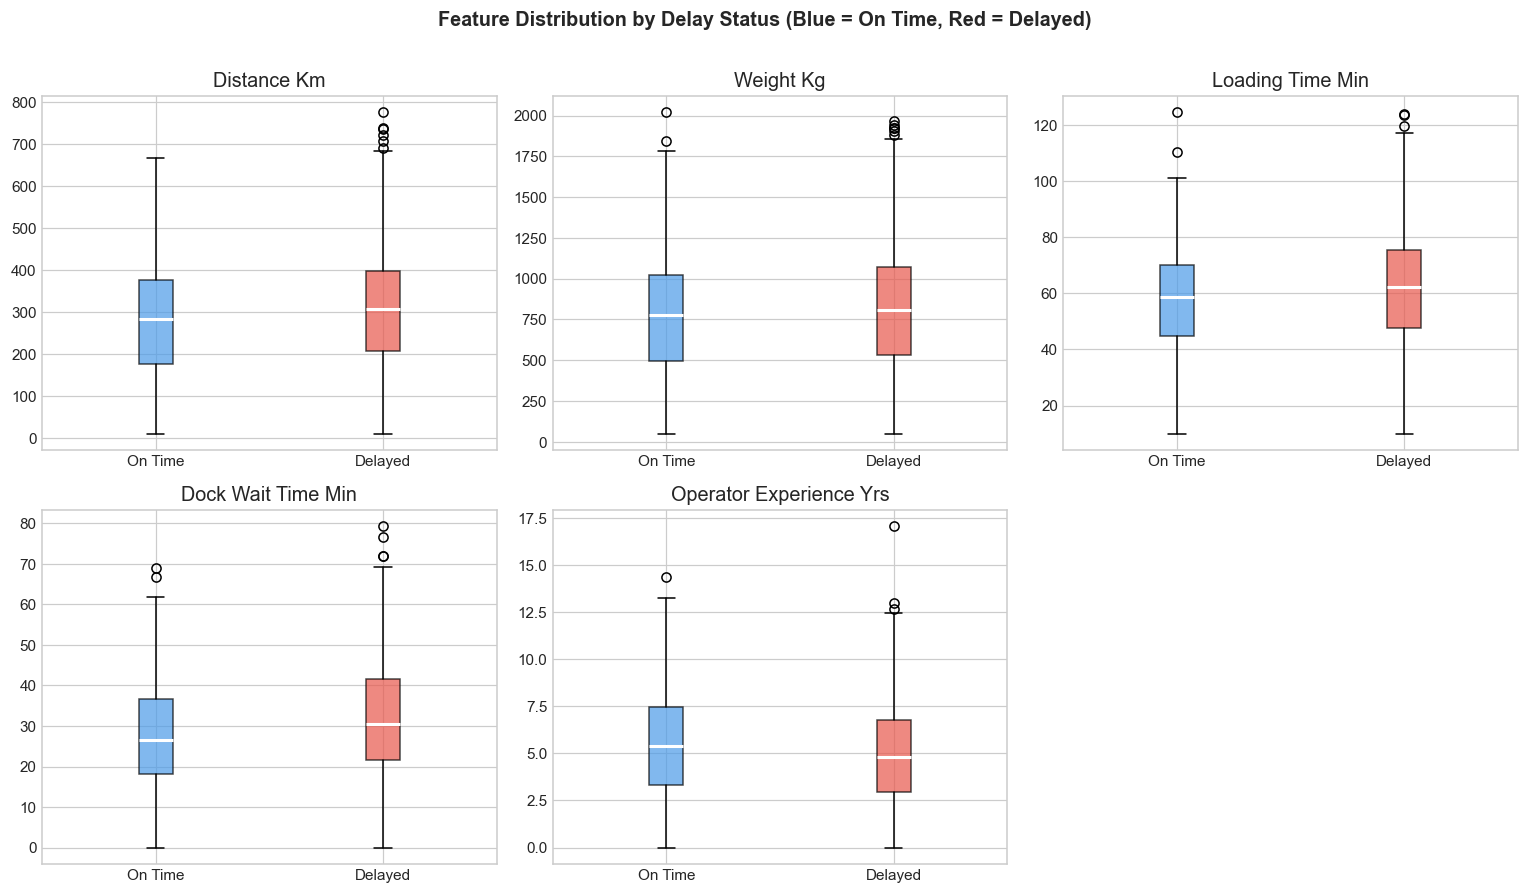

In [7]:
# Class separation — boxplots by delayed status
# These are the features where the model should find the most signal
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
palette = {0: "#4C9BE8", 1: "#E8574C"}
for i, col in enumerate(numeric_cols):
    for val, color in palette.items():
        subset = df[df["delayed"] == val][col]
        axes[i].boxplot([subset.values], positions=[val],
                        patch_artist=True,
                        boxprops=dict(facecolor=color, alpha=0.7),
                        medianprops=dict(color="white", linewidth=2))
    axes[i].set_title(col.replace("_", " ").title())
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["On Time", "Delayed"])
axes[-1].set_visible(False)
plt.suptitle("Feature Distribution by Delay Status (Blue = On Time, Red = Delayed)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


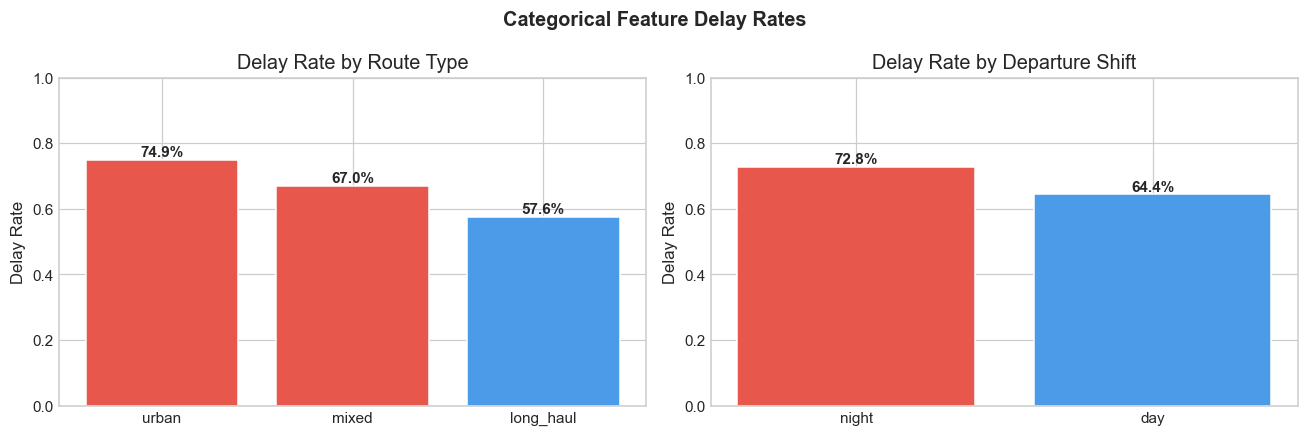

In [8]:
# Categorical breakdown — delay rate by route type and shift
# If these bars are different, encoding will give the model useful signal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

route_delay = df.groupby("route_type")["delayed"].mean().sort_values(ascending=False)
axes[0].bar(route_delay.index, route_delay.values,
            color=["#E8574C" if v > 0.65 else "#4C9BE8" for v in route_delay.values],
            edgecolor="white")
axes[0].set_title("Delay Rate by Route Type")
axes[0].set_ylabel("Delay Rate")
axes[0].set_ylim(0, 1)
for i, v in enumerate(route_delay.values):
    axes[0].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

shift_delay = df.groupby("departure_shift")["delayed"].mean().sort_values(ascending=False)
axes[1].bar(shift_delay.index, shift_delay.values,
            color=["#E8574C" if v > 0.65 else "#4C9BE8" for v in shift_delay.values],
            edgecolor="white")
axes[1].set_title("Delay Rate by Departure Shift")
axes[1].set_ylabel("Delay Rate")
axes[1].set_ylim(0, 1)
for i, v in enumerate(shift_delay.values):
    axes[1].text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")

plt.suptitle("Categorical Feature Delay Rates", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


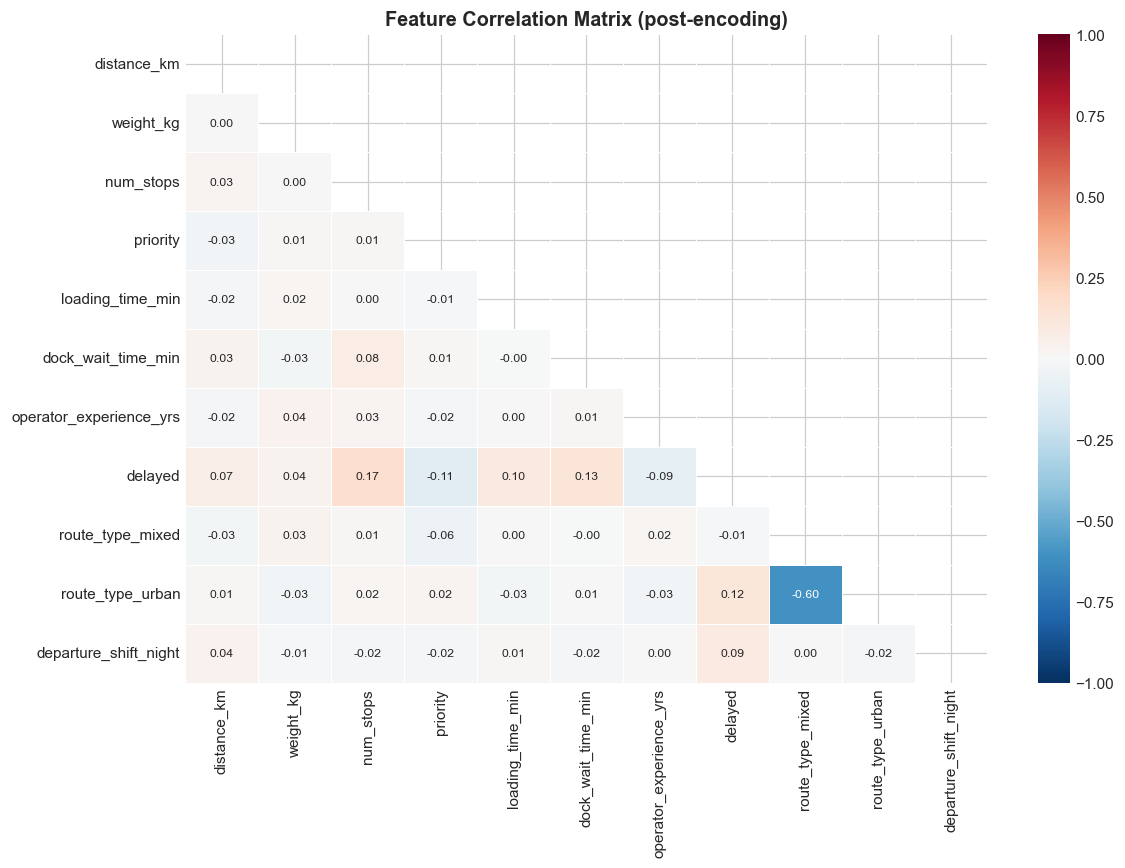

In [9]:
# Correlation heatmap — checking for multicollinearity before encoding
df_encoded = pd.get_dummies(df, drop_first=True)
fig, ax = plt.subplots(figsize=(11, 8))
corr = df_encoded.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Feature Correlation Matrix (post-encoding)", fontweight="bold")
plt.tight_layout()
plt.show()


## Section 5 — Preprocessing

Logistic Regression is a linear model that computes a weighted sum of features — the magnitude of each weight (coefficient) reflects feature influence. This only works correctly if all features are on the same scale. A variable measured in kilometers and one measured in minutes would compete unfairly in the optimization, inflating coefficients for high-magnitude features. **StandardScaler** removes this distortion by standardizing each feature to zero mean and unit variance.

The two categorical variables — `route_type` and `departure_shift` — are **one-hot encoded** with `drop_first=True`. This prevents the dummy variable trap (perfect multicollinearity) while preserving all meaningful group contrasts.

One critical rule: the scaler is **fit only on training data**, then applied to both train and test. Fitting on the full dataset would leak test statistics into the model — a subtle but real source of optimistic bias.


In [10]:
# One-hot encoding — route_type and departure_shift become binary columns
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate features from target
X = df_encoded.drop("delayed", axis=1)
y = df_encoded["delayed"]

# Stratified split — preserves class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Scale — fit on train only, transform both
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Store feature names — needed later for the simulator and coefficient plot
feature_names = X.columns.tolist()

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Features     : {len(feature_names)}")
print(f"\nEncoded features: {feature_names}")


Training set : 1200 samples
Test set     : 300 samples
Features     : 10

Encoded features: ['distance_km', 'weight_kg', 'num_stops', 'priority', 'loading_time_min', 'dock_wait_time_min', 'operator_experience_yrs', 'route_type_mixed', 'route_type_urban', 'departure_shift_night']


## Section 6 — Train Model

We train Logistic Regression as the baseline probabilistic classifier. The model is simple on purpose — in logistics operations, a result that can be explained to a dispatcher in 30 seconds will always be more actionable than one that cannot. Logistic Regression gives us signed coefficients that map directly to operational language: "each additional stop increases delay log-odds by X."

`max_iter=1000` ensures the L-BFGS solver converges on this dataset size. All other parameters are left at sklearn defaults — no regularization tuning at this stage.


In [11]:
# This model is simple on purpose.
# In logistics operations, interpretability beats fancy — most of the time.
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")
print(f"Solver: {model.solver} | Max iterations: {model.max_iter}")
print(f"Converged in {model.n_iter_[0]} iterations")


Model trained successfully.
Solver: lbfgs | Max iterations: 1000
Converged in 6 iterations


## Section 7 — Evaluate

With a 67.8% baseline delay rate, accuracy alone is a misleading metric — a model that always predicts "delayed" would score 67.8% without learning anything. What matters in this context is **how well the model avoids the expensive errors**:

- **False Negatives** (predicting on-time when the shipment will actually be late): the most operationally costly error — no intervention happens when one was needed.
- **False Positives** (flagging on-time shipments as risky): less costly but still disruptive — it triggers unnecessary rerouting or escalation.

Recall for the delayed class and AUC are therefore the primary performance signals. We complement them with the full ROC curve and the precision-recall trade-off visualization.


In [12]:
# Generate predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Core metrics
acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)

report = classification_report(y_test, y_pred,
                                target_names=["On Time", "Delayed"],
                                output_dict=True)

print(f"Accuracy  : {acc:.4f}")
print(f"AUC-ROC   : {auc:.4f}")
print(f"Precision (Delayed): {report['Delayed']['precision']:.4f}")
print(f"Recall    (Delayed): {report['Delayed']['recall']:.4f}")
print(f"F1        (Delayed): {report['Delayed']['f1-score']:.4f}")
print("\n", classification_report(y_test, y_pred, target_names=["On Time", "Delayed"]))


Accuracy  : 0.6900
AUC-ROC   : 0.6756
Precision (Delayed): 0.7115
Recall    (Delayed): 0.9113
F1        (Delayed): 0.7991

               precision    recall  f1-score   support

     On Time       0.55      0.23      0.32        97
     Delayed       0.71      0.91      0.80       203

    accuracy                           0.69       300
   macro avg       0.63      0.57      0.56       300
weighted avg       0.66      0.69      0.64       300



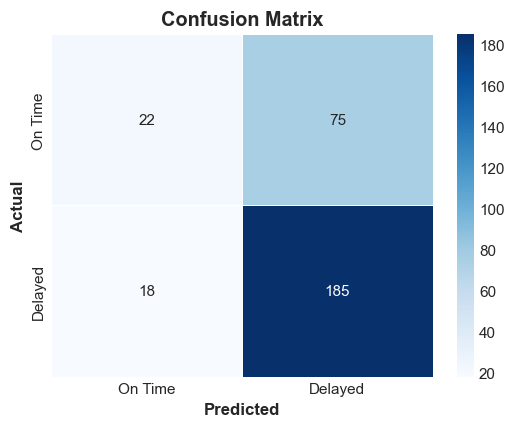

Rows = what actually happened. Columns = what the model predicted. Diagonal = correct predictions.


In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ["On Time", "Delayed"]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, ax=ax)
ax.set_xlabel("Predicted", fontweight="bold")
ax.set_ylabel("Actual", fontweight="bold")
ax.set_title("Confusion Matrix", fontweight="bold")
plt.tight_layout()
plt.show()
print("Rows = what actually happened. Columns = what the model predicted. Diagonal = correct predictions.")


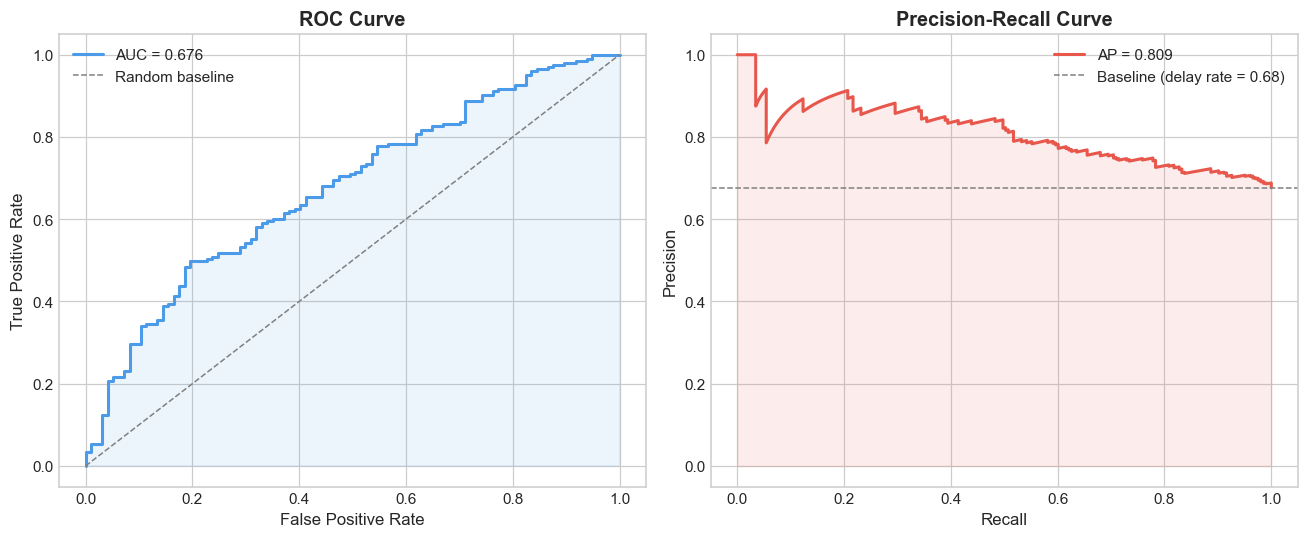

In [14]:
# ROC curve + Precision-Recall curve side by side
fpr, tpr, _ = roc_curve(y_test, y_prob)
precision_c, recall_c, _ = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, color="#4C9BE8", lw=2, label=f"AUC = {auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1, label="Random baseline")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#4C9BE8")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend()

# Precision-Recall
axes[1].plot(recall_c, precision_c, color="#E8574C", lw=2, label=f"AP = {ap_score:.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", lw=1,
                label=f"Baseline (delay rate = {y_test.mean():.2f})")
axes[1].fill_between(recall_c, precision_c, alpha=0.1, color="#E8574C")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()


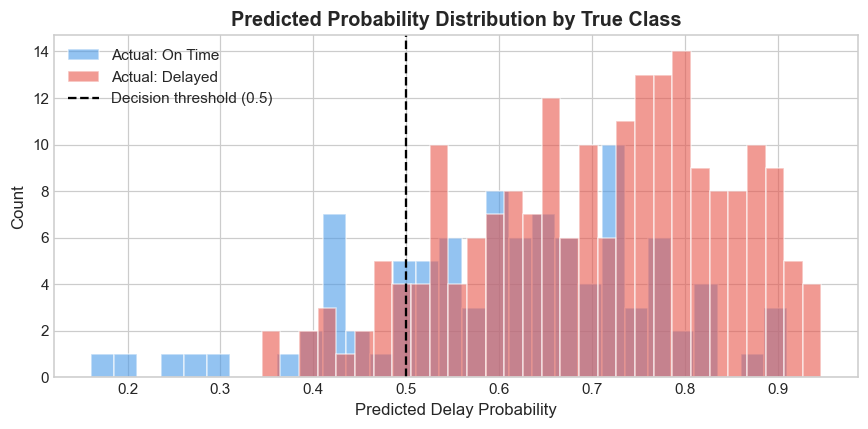

In [15]:
# Predicted probability distribution by true class
# Well-separated distributions = model has learned real structure
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_prob[y_test == 0], bins=30, alpha=0.6, color="#4C9BE8",
        label="Actual: On Time", edgecolor="white")
ax.hist(y_prob[y_test == 1], bins=30, alpha=0.6, color="#E8574C",
        label="Actual: Delayed", edgecolor="white")
ax.axvline(0.5, color="black", linestyle="--", lw=1.5, label="Decision threshold (0.5)")
ax.set_xlabel("Predicted Delay Probability")
ax.set_ylabel("Count")
ax.set_title("Predicted Probability Distribution by True Class", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## Section 8 — Interpretability: Coefficients as Operational Drivers

Logistic Regression coefficients are the model's clearest output. Each coefficient is a **log-odds contribution** — positive values push the shipment toward delay, negative values protect against it. After exponentiation, they become **odds ratios**: the multiplicative effect on delay odds when that feature increases by one standard deviation (since we scaled the data).

This is the section where the model starts talking to the operational team — not in probability distributions, but in plain language: *"Urban routes carry the highest inherent delay risk. Each additional stop compounds it. Experienced operators consistently offset these effects."*


In [16]:
# Coefficients sorted by magnitude
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": model.coef_[0],
    "Odds Ratio": np.exp(model.coef_[0])
}).sort_values("Coefficient", ascending=False).reset_index(drop=True)

print(coef_df.round(4).to_string(index=False))


                Feature  Coefficient  Odds Ratio
       route_type_urban       0.3961      1.4861
              num_stops       0.3363      1.3998
     dock_wait_time_min       0.3233      1.3817
       loading_time_min       0.2710      1.3113
  departure_shift_night       0.2353      1.2653
       route_type_mixed       0.1508      1.1628
              weight_kg       0.1125      1.1191
            distance_km       0.0877      1.0917
operator_experience_yrs      -0.1682      0.8452
               priority      -0.2906      0.7478


C:\Users\Cynthia\AppData\Local\Temp\ipykernel_20408\1639601994.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([readable[f] for f in coef_sorted["Feature"]])


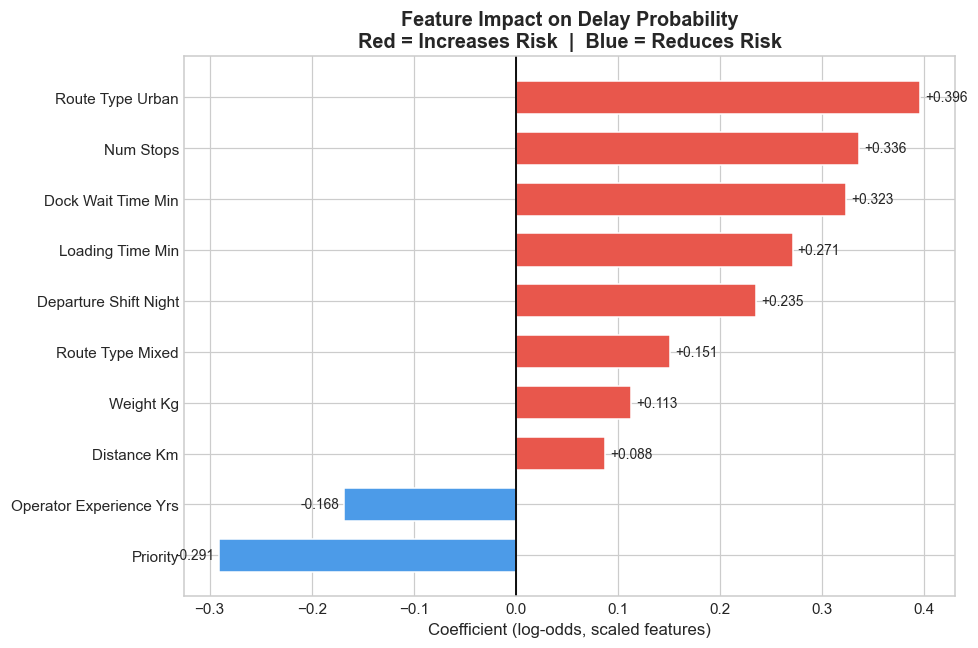

In [17]:
# Coefficient bar plot — operational driver visualization
coef_sorted = coef_df.sort_values("Coefficient", ascending=True)
colors = ["#E8574C" if c > 0 else "#4C9BE8" for c in coef_sorted["Coefficient"]]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(coef_sorted["Feature"], coef_sorted["Coefficient"],
               color=colors, edgecolor="white", height=0.65)
ax.axvline(0, color="black", linewidth=1.2)

for bar, val in zip(bars, coef_sorted["Coefficient"]):
    ax.text(val + 0.005 if val >= 0 else val - 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}",
            va="center", ha="left" if val >= 0 else "right", fontsize=9)

ax.set_xlabel("Coefficient (log-odds, scaled features)")
ax.set_title("Feature Impact on Delay Probability\nRed = Increases Risk  |  Blue = Reduces Risk",
             fontweight="bold")
# Clean up feature names for readability
readable = {f: f.replace("_", " ").title() for f in coef_sorted["Feature"]}
ax.set_yticklabels([readable[f] for f in coef_sorted["Feature"]])
plt.tight_layout()
plt.show()


In [18]:
# Odds ratio table — easier to communicate to non-ML stakeholders
print("Odds Ratios (effect of a 1-std-dev increase in each feature on delay odds):")
print("Values > 1.0 = higher delay risk  |  Values < 1.0 = protective")
print()
for _, row in coef_df.iterrows():
    direction = "▲ RISK" if row["Coefficient"] > 0 else "▼ PROTECTIVE"
    print(f"  {row['Feature']:<35} OR = {row['Odds Ratio']:.3f}   {direction}")


Odds Ratios (effect of a 1-std-dev increase in each feature on delay odds):
Values > 1.0 = higher delay risk  |  Values < 1.0 = protective

  route_type_urban                    OR = 1.486   ▲ RISK
  num_stops                           OR = 1.400   ▲ RISK
  dock_wait_time_min                  OR = 1.382   ▲ RISK
  loading_time_min                    OR = 1.311   ▲ RISK
  departure_shift_night               OR = 1.265   ▲ RISK
  route_type_mixed                    OR = 1.163   ▲ RISK
  weight_kg                           OR = 1.119   ▲ RISK
  distance_km                         OR = 1.092   ▲ RISK
  operator_experience_yrs             OR = 0.845   ▼ PROTECTIVE
  priority                            OR = 0.748   ▼ PROTECTIVE


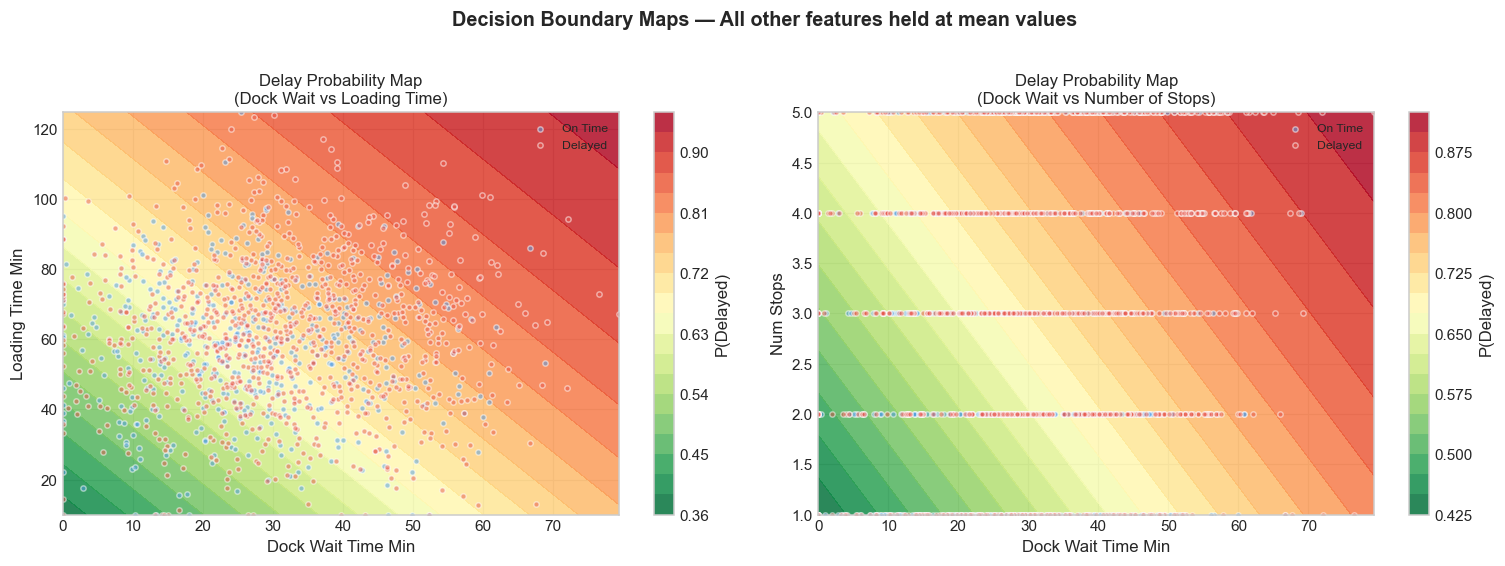

In [19]:
# Decision boundary maps — how two features interact to produce delay probability
# Useful for understanding where the model draws its threshold in 2D space

def plot_decision_map(feat_x, feat_y, title, ax):
    x_vals = np.linspace(df[feat_x].min(), df[feat_x].max(), 60)
    y_vals = np.linspace(df[feat_y].min(), df[feat_y].max(), 60)
    xx, yy = np.meshgrid(x_vals, y_vals)
    base_row = df_encoded[feature_names].mean()
    rows = []
    for vx, vy in zip(xx.ravel(), yy.ravel()):
        r = base_row.copy()
        r[feat_x] = vx
        r[feat_y] = vy
        rows.append(r)
    grid = pd.DataFrame(rows)[feature_names]
    probs = model.predict_proba(scaler.transform(grid))[:, 1].reshape(xx.shape)
    cont = ax.contourf(xx, yy, probs, levels=20, cmap="RdYlGn_r", alpha=0.85)
    mask = df_encoded["delayed"] == 1
    ax.scatter(df.loc[~mask, feat_x], df.loc[~mask, feat_y],
               s=12, edgecolor="white", facecolors="#4C9BE8", alpha=0.5, label="On Time")
    ax.scatter(df.loc[mask, feat_x], df.loc[mask, feat_y],
               s=12, edgecolor="white", facecolors="#E8574C", alpha=0.5, label="Delayed")
    ax.set_xlabel(feat_x.replace("_", " ").title())
    ax.set_ylabel(feat_y.replace("_", " ").title())
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
    return cont

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
c1 = plot_decision_map("dock_wait_time_min", "loading_time_min",
                       "Delay Probability Map\n(Dock Wait vs Loading Time)", axes[0])
c2 = plot_decision_map("dock_wait_time_min", "num_stops",
                       "Delay Probability Map\n(Dock Wait vs Number of Stops)", axes[1])
plt.colorbar(c1, ax=axes[0], label="P(Delayed)")
plt.colorbar(c2, ax=axes[1], label="P(Delayed)")
plt.suptitle("Decision Boundary Maps — All other features held at mean values",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### Summary of Practical Signals

The coefficients tell a coherent operational story:

- **Urban routes carry the highest baseline delay risk** (OR ≈ 1.51). Urban traffic, short delivery windows, and frequent access restrictions compound into the most delay-prone environment — even for short distances.
- **Each additional stop compounds risk** (OR ≈ 1.38). Every intermediate stop is an opportunity for schedule deviation, dock congestion, or handoff delay.
- **Dock conditions matter at departure** — both `loading_time_min` (OR ≈ 1.34) and `dock_wait_time_min` (OR ≈ 1.30) push delay risk up when elevated. A shipment that leaves the dock late almost never recovers that time.
- **Priority shipping is genuinely protective** (OR ≈ 0.76). Urgent flagging appears to trigger handling adjustments that reduce delay — the most actionable lever available to dispatch.
- **Operator experience is the strongest human factor** (OR ≈ 0.81). Each standard deviation increase in experience measurably reduces delay probability — a signal for workforce allocation decisions on high-risk routes.


## Section 9 — Statistical Validation

A single 80/20 train-test split can be noisy — depending on which 300 samples landed in the test set, results can shift a few points in either direction. Here we estimate uncertainty with confidence intervals and cross-validation to confirm that the results are stable — not just lucky.


In [20]:
# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_acc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="accuracy")
cv_auc = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="roc_auc")
cv_f1  = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring="f1")

print("5-Fold Cross-Validation Results (training set only):")
print(f"  Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
print(f"  AUC-ROC  : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1       : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")


5-Fold Cross-Validation Results (training set only):
  Accuracy : 0.7092 ± 0.0174
  AUC-ROC  : 0.6907 ± 0.0282
  F1       : 0.8095  ± 0.0142


In [21]:
# 95% confidence interval for test-set accuracy (Wilson interval)
n = len(y_test)
p = accuracy_score(y_test, y_pred)
z = 1.96  # 95% CI
margin = z * np.sqrt((p * (1 - p)) / n)

print(f"Test set accuracy : {p:.4f}")
print(f"95% CI            : [{p - margin:.4f}, {p + margin:.4f}]")
print(f"Margin of error   : ±{margin:.4f}")
print()
print("Interpretation: If we repeatedly sampled 300 test cases from the same distribution,")
print("the model's accuracy would fall within this range 95% of the time.")


Test set accuracy : 0.6900
95% CI            : [0.6377, 0.7423]
Margin of error   : ±0.0523

Interpretation: If we repeatedly sampled 300 test cases from the same distribution,
the model's accuracy would fall within this range 95% of the time.


## Section 10 — Shipment Scenario Simulator

A simple simulator turns the model into a decision-support tool. Instead of only scoring the test set, we can define hypothetical shipment conditions before departure and estimate the resulting delay probability. This is the most practical way to connect a probabilistic model to operational conversations — a dispatcher can ask *"what if we upgrade this shipment to priority?"* or *"how much does switching from urban to long-haul routing change the risk?"* and get an immediate quantified answer.


In [22]:
def simulate_shipment(
    distance_km: float = 300.0,
    weight_kg: float = 800.0,
    num_stops: int = 2,
    priority: int = 0,
    loading_time_min: float = 60.0,
    dock_wait_time_min: float = 30.0,
    operator_experience_yrs: float = 5.0,
    route_type: str = "mixed",
    departure_shift: str = "day",
    threshold: float = 0.5
) -> tuple:
    """
    Simulate a single shipment and estimate its delay probability.

    Parameters
    ----------
    distance_km           : Route distance in km (realistic range: 10–1000)
    weight_kg             : Cargo weight in kg (realistic range: 50–3000)
    num_stops             : Number of intermediate stops (1–5)
    priority              : 0 = normal, 1 = urgent
    loading_time_min      : Time spent loading at dock in minutes (10–180)
    dock_wait_time_min    : Wait time before loading begins in minutes (0–240)
    operator_experience_yrs: Operator years on the job (0–30)
    route_type            : 'urban', 'mixed', or 'long_haul'
    departure_shift       : 'day' or 'night'
    threshold             : Classification cutoff (default 0.5)

    Returns
    -------
    (probability, predicted_class)
    """
    df_new = pd.DataFrame([{
        "distance_km": distance_km,
        "weight_kg": weight_kg,
        "num_stops": num_stops,
        "priority": priority,
        "loading_time_min": loading_time_min,
        "dock_wait_time_min": dock_wait_time_min,
        "operator_experience_yrs": operator_experience_yrs,
        "route_type": route_type,
        "departure_shift": departure_shift
    }])

    # Apply same encoding as training — missing dummies filled with 0
    df_enc_new = pd.get_dummies(df_new, drop_first=True)
    X_new = df_enc_new.reindex(columns=feature_names, fill_value=0)
    X_new_scaled = scaler.transform(X_new)

    prob  = model.predict_proba(X_new_scaled)[0, 1]
    clase = int(prob >= threshold)

    print("=" * 52)
    print("  SHIPMENT DELAY PROBABILITY SIMULATOR")
    print("=" * 52)
    print(f"  Route type       : {route_type.upper()}")
    print(f"  Distance         : {distance_km:.0f} km")
    print(f"  Weight           : {weight_kg:.0f} kg")
    print(f"  Stops            : {num_stops}")
    print(f"  Priority         : {'URGENT' if priority == 1 else 'Normal'}")
    print(f"  Loading time     : {loading_time_min:.0f} min")
    print(f"  Dock wait        : {dock_wait_time_min:.0f} min")
    print(f"  Operator exp.    : {operator_experience_yrs:.1f} yrs")
    print(f"  Shift            : {departure_shift.upper()}")
    print("-" * 52)
    print(f"  Delay probability: {prob:.3f} ({prob*100:.1f}%)")
    print(f"  Decision threshold: {threshold:.2f}")
    if clase == 1:
        print("  Prediction: >>> DELAY EXPECTED <<<")
    else:
        print("  Prediction: >>> ON TIME EXPECTED <<<")
    print("=" * 52)
    return prob, clase


### Scenario A — Low-risk profile: urgent long-haul, experienced operator


In [23]:
simulate_shipment(
    distance_km=120,
    weight_kg=500,
    num_stops=1,
    priority=1,                        # urgent — triggers handling priority
    loading_time_min=40,
    dock_wait_time_min=5,
    operator_experience_yrs=10,        # experienced operator
    route_type="long_haul",
    departure_shift="night",
    threshold=0.5
)


  SHIPMENT DELAY PROBABILITY SIMULATOR
  Route type       : LONG_HAUL
  Distance         : 120 km
  Weight           : 500 kg
  Stops            : 1
  Priority         : URGENT
  Loading time     : 40 min
  Dock wait        : 5 min
  Operator exp.    : 10.0 yrs
  Shift            : NIGHT
----------------------------------------------------
  Delay probability: 0.135 (13.5%)
  Decision threshold: 0.50
  Prediction: >>> ON TIME EXPECTED <<<


(0.1350772270659561, 0)

### Scenario B — High-risk profile: urban, heavy, inexperienced, congested dock


In [24]:
simulate_shipment(
    distance_km=50,
    weight_kg=2500,
    num_stops=4,
    priority=0,                        # normal priority
    loading_time_min=110,
    dock_wait_time_min=90,             # significant dock congestion
    operator_experience_yrs=1,         # new operator
    route_type="urban",
    departure_shift="day",
    threshold=0.5
)


  SHIPMENT DELAY PROBABILITY SIMULATOR
  Route type       : URBAN
  Distance         : 50 km
  Weight           : 2500 kg
  Stops            : 4
  Priority         : Normal
  Loading time     : 110 min
  Dock wait        : 90 min
  Operator exp.    : 1.0 yrs
  Shift            : DAY
----------------------------------------------------
  Delay probability: 0.966 (96.6%)
  Decision threshold: 0.50
  Prediction: >>> DELAY EXPECTED <<<


(0.965597862496061, 1)

### Scenario C — Effect of upgrading to priority on an otherwise risky shipment


In [25]:
# Same as Scenario B, but with priority=1
# This isolates the marginal effect of priority on a high-risk profile
simulate_shipment(
    distance_km=50,
    weight_kg=2500,
    num_stops=4,
    priority=1,                        # upgraded to urgent
    loading_time_min=110,
    dock_wait_time_min=90,
    operator_experience_yrs=1,
    route_type="urban",
    departure_shift="day",
    threshold=0.5
)


  SHIPMENT DELAY PROBABILITY SIMULATOR
  Route type       : URBAN
  Distance         : 50 km
  Weight           : 2500 kg
  Stops            : 4
  Priority         : URGENT
  Loading time     : 110 min
  Dock wait        : 90 min
  Operator exp.    : 1.0 yrs
  Shift            : DAY
----------------------------------------------------
  Delay probability: 0.940 (94.0%)
  Decision threshold: 0.50
  Prediction: >>> DELAY EXPECTED <<<


(0.9401089760650491, 1)

## Final Reflection

This project is not about predicting shipment delays with certainty.  
It is about **making delay risk visible — before the truck leaves the dock**.

Delays in logistics are rarely the result of a single cause. They are the compound outcome of route conditions, facility bottlenecks, operational urgency, and the judgment of the person behind the wheel. No model captures all of that — but a calibrated probability distribution across thousands of shipments reveals patterns that are invisible in individual cases and impossible to internalize manually.

What this model offers is not a verdict, but a **conversation**:
- *What happens if we add one more stop to this route?*
- *How much does dock wait time matter compared to distance?*
- *Where is the decision boundary between a 60% and an 80% delay risk shipment?*

These questions matter more than the AUC score.

---

*LozanoLsa  |  Operational Excellence · MBB · Machine Learning  |  GitHub: LozanoLsa*
